**DATAFRAME**

In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create a dataset
# Let´s build the values lists
value_n_list = ['Andrew', 'Phillip', 'John',"Rose","Laura","Jairo","Luisa","Cristian","María","Drake"]
print(value_n_list)

value_w_list = [50,78,91.5,50.2,65,82,40.5,74,69.4,58] # [kg]
value_h_list = [1.76,1.87,1.69,1.48,1.59,1.98,1.56,1.87,1.68,1.75] # [m]
# value_bmi_list will be calculated: bmi = w/(h^2)
#value_bmi_list = [25,25,25] # init values [kg/m2]

# Let´s use a dictionary ({key:value})
# with the format {"str":list}
data_dict = {"name":value_n_list,
             "weight":value_w_list,
             "height":value_h_list} #,
              #"BMI":value_bmi_list}

print(data_dict)

# Turn a dictionary into a dataframe
df = pd.DataFrame(data_dict)

print()
print(df)
# Call a variable
print()
df

['Andrew', 'Phillip', 'John', 'Rose', 'Laura', 'Jairo', 'Luisa', 'Cristian', 'María', 'Drake']
{'name': ['Andrew', 'Phillip', 'John', 'Rose', 'Laura', 'Jairo', 'Luisa', 'Cristian', 'María', 'Drake'], 'weight': [50, 78, 91.5, 50.2, 65, 82, 40.5, 74, 69.4, 58], 'height': [1.76, 1.87, 1.69, 1.48, 1.59, 1.98, 1.56, 1.87, 1.68, 1.75]}

       name  weight  height
0    Andrew    50.0    1.76
1   Phillip    78.0    1.87
2      John    91.5    1.69
3      Rose    50.2    1.48
4     Laura    65.0    1.59
5     Jairo    82.0    1.98
6     Luisa    40.5    1.56
7  Cristian    74.0    1.87
8     María    69.4    1.68
9     Drake    58.0    1.75



,name,weight,height
0,Andrew,50.0,1.76
1,Phillip,78.0,1.87
2,John,91.5,1.69
3,Rose,50.2,1.48
4,Laura,65.0,1.59
5,Jairo,82.0,1.98
6,Luisa,40.5,1.56
7,Cristian,74.0,1.87
8,María,69.4,1.68
9,Drake,58.0,1.75


**SE AÑADIERON 9990 REGISTROS EN EL DF**

In [ ]:
import sys
!{sys.executable} -m pip install faker


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.6 MB/s eta 0:00:00


In [ ]:
from faker import Faker
import numpy as np
import pandas as pd

# Initialize Faker with 'es_ES' locale
faker = Faker('es_ES')

# Number of additional records needed
num_additional_records = 9990

# Generate 9,990 single Spanish names
additional_names = [faker.first_name() for _ in range(num_additional_records)]

# Define parameters for weight generation
mean_weight = 65  # kg
std_dev_weight = 10  # kg
min_weight = 45 # kg
max_weight = 90 # kg

# Generate 9,990 weight values and clip them
additional_weights = np.random.normal(loc=mean_weight, scale=std_dev_weight, size=num_additional_records)
additional_weights = np.clip(additional_weights, min_weight, max_weight)

# Define parameters for height generation (using previous context's mean and std_dev if not specified)
mean_height = 1.70  # m
std_dev_height = 0.1  # m
min_height = 1.46 # m
max_height = 2.00 # m

# Generate 9,990 height values and clip them
additional_heights = np.random.normal(loc=mean_height, scale=std_dev_height, size=num_additional_records)
additional_heights = np.clip(additional_heights, min_height, max_height)

# Create a new DataFrame for the additional records
additional_data_dict = {
    'name': additional_names,
    'weight': additional_weights,
    'height': additional_heights
}
df_additional = pd.DataFrame(additional_data_dict)

# Assuming 'df' currently holds the initial 10 records
# If 'df' has been modified elsewhere, ensure to re-initialize it to the original 10 records
# For this task, I will concatenate with the existing 'df' variable in the kernel.

# Concatenate the original df with the additional DataFrame
df = pd.concat([df, df_additional], ignore_index=True)

print("DataFrame 'df' has been successfully expanded.")
print(f"New shape of df: {df.shape}")



DataFrame 'df' has been successfully expanded.
New shape of df: (10000, 3)


In [ ]:
df

,name,weight,height
0,Andrew,50.000000,1.760000
1,Phillip,78.000000,1.870000
2,John,91.500000,1.690000
3,Rose,50.200000,1.480000
4,Laura,65.000000,1.590000
...,...,...,...
9995,Humberto,72.758811,1.777733
9996,Juan Manuel,73.057283,1.655718
9997,Cándida,69.475096,1.621620
9998,Montserrat,58.771387,1.837216


In [ ]:
# prompt: Con DataFrame df: add another column

#Si uno hace una operación directamente en una columna, esta operación se va a realizar en todo
#Aqui voy a crear una nueva columna que se llama bmi teniendo encuenta los valores de las columnas weight y height

df['bmi'] = df['weight'] / (df['height'] ** 2)
df


,name,weight,height,bmi
0,Andrew,50.000000,1.760000,16.141529
1,Phillip,78.000000,1.870000,22.305471
2,John,91.500000,1.690000,32.036693
3,Rose,50.200000,1.480000,22.918188
4,Laura,65.000000,1.590000,25.711008
...,...,...,...,...
9995,Humberto,72.758811,1.777733,23.022502
9996,Juan Manuel,73.057283,1.655718,26.649608
9997,Cándida,69.475096,1.621620,26.419903
9998,Montserrat,58.771387,1.837216,17.411874


In [ ]:
#Define una funciion para determinar la condicion de salud
def determine_health_condition(bmi):
    if 18.0 <= bmi <= 25.0:
        return 'Peso normal'
    if bmi < 18.0:
        return 'Bajo peso'
    if bmi > 25.0:
        return 'Sobrepeso'

# Aplicar la funcion a la columna
df['health_condition'] = df['bmi'].apply(determine_health_condition)
df

,name,weight,height,bmi,health_condition
0,Andrew,50.000000,1.760000,16.141529,Bajo peso
1,Phillip,78.000000,1.870000,22.305471,Peso normal
2,John,91.500000,1.690000,32.036693,Sobrepeso
3,Rose,50.200000,1.480000,22.918188,Peso normal
4,Laura,65.000000,1.590000,25.711008,Sobrepeso
...,...,...,...,...,...
9995,Humberto,72.758811,1.777733,23.022502,Peso normal
9996,Juan Manuel,73.057283,1.655718,26.649608,Sobrepeso
9997,Cándida,69.475096,1.621620,26.419903,Sobrepeso
9998,Montserrat,58.771387,1.837216,17.411874,Bajo peso


In [ ]:
apellidos=10000
df['apellido'] = [faker.last_name() for _ in range(apellidos)]
df

,name,weight,height,bmi,health_condition,apellido
0,Andrew,50.000000,1.760000,16.141529,Bajo peso,Mena
1,Phillip,78.000000,1.870000,22.305471,Peso normal,Benet
2,John,91.500000,1.690000,32.036693,Sobrepeso,Criado
3,Rose,50.200000,1.480000,22.918188,Peso normal,Peñalver
4,Laura,65.000000,1.590000,25.711008,Sobrepeso,Abad
...,...,...,...,...,...,...
9995,Humberto,72.758811,1.777733,23.022502,Peso normal,Castejón
9996,Juan Manuel,73.057283,1.655718,26.649608,Sobrepeso,Melero
9997,Cándida,69.475096,1.621620,26.419903,Sobrepeso,Diego
9998,Montserrat,58.771387,1.837216,17.411874,Bajo peso,Ruano


In [ ]:
edades=10000
df['edad']=[faker.random_int(min=18, max=70) for _ in range(edades)]
df


,name,weight,height,bmi,health_condition,apellido,edad
0,Andrew,50.000000,1.760000,16.141529,Bajo peso,Mena,56
1,Phillip,78.000000,1.870000,22.305471,Peso normal,Benet,35
2,John,91.500000,1.690000,32.036693,Sobrepeso,Criado,42
3,Rose,50.200000,1.480000,22.918188,Peso normal,Peñalver,45
4,Laura,65.000000,1.590000,25.711008,Sobrepeso,Abad,39
...,...,...,...,...,...,...,...
9995,Humberto,72.758811,1.777733,23.022502,Peso normal,Castejón,36
9996,Juan Manuel,73.057283,1.655718,26.649608,Sobrepeso,Melero,21
9997,Cándida,69.475096,1.621620,26.419903,Sobrepeso,Diego,18
9998,Montserrat,58.771387,1.837216,17.411874,Bajo peso,Ruano,65


**ANALISIS ESTADISTICO**

In [ ]:
round(df.describe(),3)

,weight,height,bmi,edad
count,10000.000,10000.000,10000.000,10000.000
mean,64.974,1.701,22.667,43.985
std,9.638,0.099,4.259,15.263
min,40.500,1.460,11.785,18.000
25%,58.271,1.634,19.670,30.750
50%,64.958,1.701,22.447,44.000
75%,71.617,1.768,25.394,57.000
max,91.500,2.000,40.359,70.000


In [ ]:
#Estaditica descriptiva
df_stats = round(df.describe(),3)
df_stats

#rango intercuantil 25%-75%, si es menor que no hay tanta variabilidad

,weight,height,bmi,edad
count,10000.000,10000.000,10000.000,10000.000
mean,64.974,1.701,22.667,43.985
std,9.638,0.099,4.259,15.263
min,40.500,1.460,11.785,18.000
25%,58.271,1.634,19.670,30.750
50%,64.958,1.701,22.447,44.000
75%,71.617,1.768,25.394,57.000
max,91.500,2.000,40.359,70.000


**Promedio:**

La media de weight es 64.958 kg, lo que indica que el peso promedio en tu conjunto de datos es aproximadamente 65 kg

**Desviación Estandar:**

La desviación de 9.70 en el peso sugiere que la mayoría de las personas pesan entre 55kg y 74kg

La desviación en edad (15.34) indica una alta diversidad generacional en la muestra

**Minimo:**

El BMI mínimo de 11.25 es extremadamente bajo (podría indicar casos de desnutrición clínica o errores de entrada de datos)

**Cuartiles**

Primer Cuartil: El 25% de la población tiene, menos de 31 años y pesa
menos de 58.2 kg

Segundo caurtil: Es el valor central; el 50% de las personas mide menos de 1.698 m y el otro 50% mide más. Como la mediana (1.698) es casi igual a la media (1.699), puede indicar una distribución normal/simétrica en la altura

Tercer Cuartil: El 75% de la muestra tiene un BMI inferior a 25.48. Esto significa que solo el 25% superior entra en categorías de sobrepeso o superior

**Máximo:**

El peso máximo es 91.5 kg y la altura máxima es 2.00 m


<Axes: >

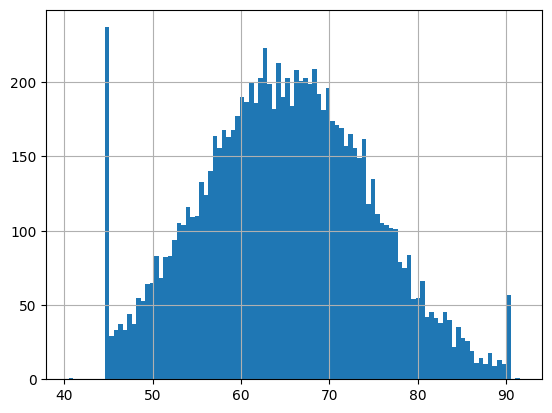

In [ ]:
df["weight"].hist(bins=100)

<Axes: >

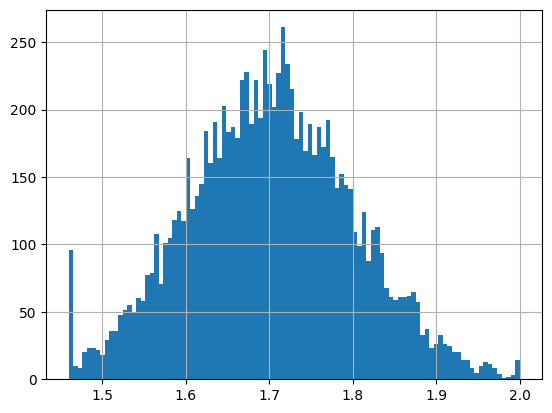

In [ ]:
df["height"].hist(bins=100)

<Axes: >

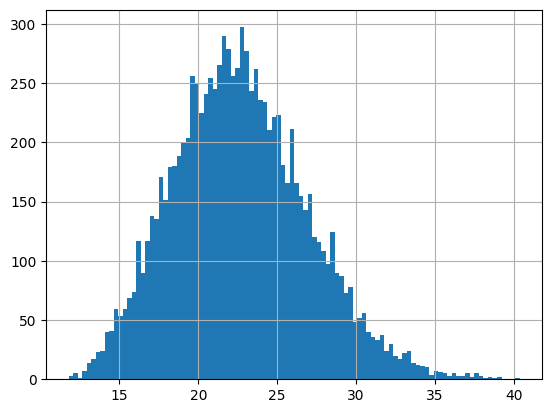

In [ ]:
df["bmi"].hist(bins=100)

<Axes: >

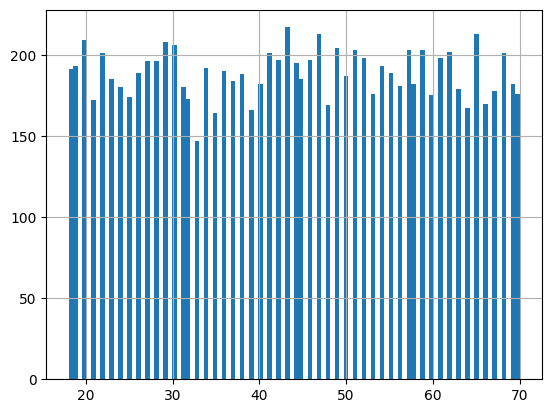

In [ ]:
df["edad"].hist(bins=100)

In [ ]:
#De que tipo es la columna
df["bmi"].dtype

dtype('float64')

In [ ]:
df["name"].dtype

dtype('O')

In [ ]:
#Cuando realizamos una matriz de correlación y el signo es negativo, la relación de las variables es inversa

#Que es un EDA (pasos)
#Buscar la operación de la correlación
#Consultar como hacer la matriz de correlación
#Incluir formulas como si estuvieran escritas en un tablero
#Consultar que es y como funciona la matriz de confusión (clasificación)
#Consultar metricas de desempeño par aregresión y clasificación

# **EDA**

EDA (Exploratory Data Analysis) es un enfoque para analizar conjuntos de datos para resumir sus características principales, a menudo con métodos visuales. Un científico de datos puede utilizar EDA para comprender mejor los datos, como identificar patrones,detectar anomalías, probar hipótesis o verificar suposiciones. No es un método formal sino una filosofía para acercarse a un conjunto de datos.

**Los pasos típicos de un EDA son:**

* Comprensión de los datos:

Cargar los datos y revisar las primeras filas (df.head()).
Obtener información general sobre el DataFrame (df.info()) para ver tipos de datos, valores no nulos y uso de memoria.
Consultar estadísticas descriptivas (df.describe()) para columnas numéricas.
Verificar los nombres de las columnas y los tipos de datos de cada columna.

* Limpieza de datos:

Manejar valores faltantes: identificar cuántos valores faltan y decidir cómo tratarlos (eliminar filas/columnas, imputar con media, mediana, moda, etc.).
Identificar y manejar duplicados.Corregir errores de formato o entrada de datos.

* Análisis de variables individuales (Univariado):

Para variables numéricas: Histogramas, diagramas de caja, densidades para entender la distribución, la dispersión, la simetría y la presencia de valores atípicos.
Para variables categóricas: Gráficos de barras para ver la frecuencia de cada categoría.

* Análisis de la relación entre variables (Bivariado y Multivariado):

Numérica vs. Numérica: Gráficos de dispersión para visualizar la relación, calcular coeficientes de correlación (Pearson, Spearman) para medir la fuerza y dirección de la relación.
Numérica vs. Categórica: Diagramas de caja, gráficos de violín o gráficos de barras agrupadas para comparar distribuciones numéricas entre diferentes categorías.
Categórica vs. Categórica: Tablas de contingencia, gráficos de barras apiladas o agrupadas.

* Detección de valores atípicos (Outliers):

Utilizar métodos estadísticos (IQR, Z-score) o visualizaciones (diagramas de caja, gráficos de dispersión) para identificar y comprender los valores atípicos.

* Ingeniería de características (Feature Engineering, si es necesario):

Crear nuevas variables a partir de las existentes que puedan ser más útiles para el modelado.

* Visualización de datos:

Utilizar gráficos apropiados para comunicar los hallazgos de manera efectiva (histogramas, gráficos de barras, gráficos de dispersión, mapas de calor para correlaciones, etc.).


# Formula de Correlación

La **Correlación de Pearson (r)** mide la fuerza y la dirección de la relación lineal entre dos variables numéricas, X e Y. Su fórmula es:

$$ r = \frac{n\sum(xy) - (\sum x)(\sum y)}{\sqrt{[n\sum x^2 - (\sum x)^2][n\sum y^2 - (\sum y)^2]}} $$

Donde:
*   $n$ es el número de pares de datos.
*   $\sum xy$ es la suma de los productos de los valores correspondientes de X e Y.
*   $\sum x$ es la suma de los valores de X.
*   $\sum y$ es la suma de los valores de Y.
*   $\sum x^2$ es la suma de los cuadrados de los valores de X.
*   $\sum y^2$ es la suma de los cuadrados de los valores de Y.

El coeficiente de correlación $r$ siempre estará entre -1 y 1:
*   **$r = 1$**: Correlación lineal positiva perfecta.
*   **$r = -1$**: Correlación lineal negativa perfecta.
*   **$r = 0$**: No hay correlación lineal.

# Matriz de correlación

Una **Matriz de Correlación** es una tabla donde se muestran los coeficientes de correlación entre múltiples variables. Cada celda de la tabla en la fila `i` y columna `j` es el coeficiente de correlación entre las variables `i` y `j`.

*   Los valores van de -1 a 1.
*   Un valor de 1 indica una correlación positiva perfecta.
*   Un valor de -1 indica una correlación negativa perfecta.
*   Un valor cercano a 0 indica poca o ninguna correlación lineal.

In [ ]:
correlation_matrix = df.corr(numeric_only=True)
display(correlation_matrix)

,weight,height,bmi,edad
weight,1.000000,0.015425,0.777520,-0.006835
height,0.015425,1.000000,-0.606201,-0.008988
bmi,0.777520,-0.606201,1.000000,-0.000639
edad,-0.006835,-0.008988,-0.000639,1.000000


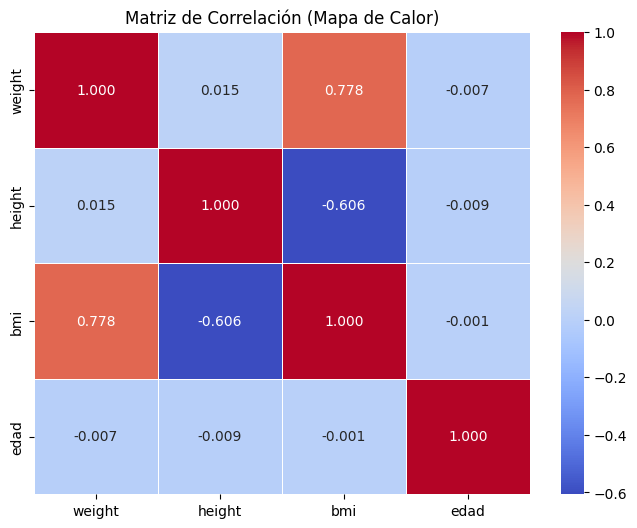

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=.5)
plt.title('Matriz de Correlación (Mapa de Calor)')
plt.show()

# Matriz de Confusión

Una **Matriz de Confusión** es una tabla que se utiliza para describir el rendimiento de un modelo de clasificación en un conjunto de datos para los cuales los valores verdaderos se conocen. Permite visualizar el rendimiento de un algoritmo, especialmente cuando hay un desequilibrio de clases en los datos.

### **Componentes de una Matriz de Confusión**

Para un problema de clasificación binaria (dos clases, por ejemplo, 'Positivo' y 'Negativo'), la matriz de confusión tiene cuatro componentes principales:

*   **Verdaderos Positivos (VP):** Son los casos en los que el modelo predijo correctamente la clase positiva. El modelo predijo 'Positivo' y el valor real era 'Positivo'.
*   **Verdaderos Negativos (VN):** Son los casos en los que el modelo predijo correctamente la clase negativa. El modelo predijo 'Negativo' y el valor real era 'Negativo'.
*   **Falsos Positivos (FP):** También conocidos como errores de Tipo I. Son los casos en los que el modelo predijo la clase positiva incorrectamente. El modelo predijo 'Positivo' pero el valor real era 'Negativo'.
*   **Falsos Negativos (FN):** También conocidos como errores de Tipo II. Son los casos en los que el modelo predijo la clase negativa incorrectamente. El modelo predijo 'Negativo' pero el valor real era 'Positivo'.

### **Cómo funciona**

La matriz se estructura típicamente de la siguiente manera:

|                   | **Predicción Positiva** | **Predicción Negativa** |
| :---------------- | :---------------------- | :---------------------- |
| **Real Positivo** | Verdaderos Positivos (VP) | Falsos Negativos (FN)   |
| **Real Negativo** | Falsos Positivos (FP)   | Verdaderos Negativos (VN) |



Para usarla:

1.  **Entrenamiento del Modelo:** Primero, se entrena un modelo de clasificación con un conjunto de datos.
2.  **Predicción:** Luego, se usa el modelo entrenado para hacer predicciones sobre un conjunto de datos de prueba (donde las etiquetas verdaderas son conocidas, pero no se usaron en el entrenamiento).
3.  **Comparación:** Se comparan las predicciones del modelo con las etiquetas verdaderas del conjunto de prueba.
4.  **Conteo:** Se cuentan los VP, VN, FP y FN, y se organizan en la tabla de la matriz de confusión.

### **Métricas derivadas**

A partir de los valores de la matriz de confusión, se pueden calcular varias métricas de rendimiento clave:

*   **Precisión (Accuracy):** (VP + VN) / Total de Casos. Mide la proporción de predicciones correctas sobre el total.
*   **Sensibilidad (Recall o Exhaustividad):** VP / (VP + FN). Mide la proporción de positivos reales que fueron identificados correctamente.
*   **Especificidad:** VN / (VN + FP). Mide la proporción de negativos reales que fueron identificados correctamente.
*   **Precisión (Precision):** VP / (VP + FP). Mide la proporción de predicciones positivas que fueron realmente correctas.
*   **Puntuación F1:** Es la media armónica de la Precisión y la Sensibilidad, útil cuando se busca un equilibrio entre ambas.

### Matriz de Confusión para Clasificación Multiclase

Cuando el problema de clasificación no es binario (es decir, hay más de dos clases), la matriz de confusión se expande. En lugar de una matriz 2x2, tendremos una matriz NxN, donde N es el número de clases.

Cada fila de la matriz representa las instancias en una clase real, mientras que cada columna representa las instancias en una clase predicha.

**Ejemplo para 3 Clases (Clase A, Clase B, Clase C):**

|                   | **Predicción Clase A** | **Predicción Clase B** | **Predicción Clase C** |
| :---------------- | :--------------------- | :--------------------- | :--------------------- |
| **Real Clase A**  | VP (Clase A)           | FP (Clase B para A)    | FP (Clase C para A)    |
| **Real Clase B**  | FN (Clase A para B)    | VP (Clase B)           | FP (Clase C para B)    |
| **Real Clase C**  | FN (Clase A para C)    | FN (Clase B para C)    | VP (Clase C)           |

En este escenario:

*   Los elementos en la **diagonal principal** (por ejemplo, intersección de 'Real Clase A' y 'Predicción Clase A') son los **Verdaderos Positivos (VP)** para esa clase específica. Indican cuántas instancias de esa clase fueron correctamente clasificadas.
*   Los elementos **fuera de la diagonal principal** representan los errores del modelo:
    *   Si miras una **fila específica**, los elementos fuera de la diagonal son **Falsos Negativos (FN)** para esa clase. Por ejemplo, en la fila 'Real Clase A', los valores en las columnas 'Predicción Clase B' y 'Predicción Clase C' indican cuántas instancias de la Clase A fueron erróneamente clasificadas como Clase B o Clase C, respectivamente.
    *   Si miras una **columna específica**, los elementos fuera de la diagonal son **Falsos Positivos (FP)** para esa clase. Por ejemplo, en la columna 'Predicción Clase A', los valores en las filas 'Real Clase B' y 'Real Clase C' indican cuántas instancias de Clase B o Clase C fueron erróneamente clasificadas como Clase A.

### Métricas en Clasificación Multiclase

Para clasificación multiclase, las métricas de Precisión, Sensibilidad (Recall), Especificidad y Puntuación F1 se pueden calcular de varias maneras:

*   **Macro-averaged:** Calcula la métrica para cada clase de forma independiente y luego toma el promedio. Le da el mismo peso a cada clase, independientemente de su tamaño.
*   **Micro-averaged:** Calcula la métrica globalmente, contando el total de VP, FN y FP a través de todas las clases. Esto es útil cuando hay un desequilibrio de clases, ya que las clases más grandes contribuyen más al promedio.
*   **Weighted-averaged:** Calcula la métrica para cada clase y luego toma el promedio ponderado por el número de instancias de cada clase. Esto da más importancia a las clases con más muestras.

La elección del tipo de promedio depende del objetivo del análisis y de la naturaleza del conjunto de datos.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Inicializar el LabelEncoder
le = LabelEncoder()

# Aplicar el codificador a la columna 'health_condition'
df['health_condition_encoded'] = le.fit_transform(df['health_condition'])

# Mostrar las primeras filas y las clases codificadas
print(df[['health_condition', 'health_condition_encoded']].head())
print(f"Clases originales: {le.classes_}")
print(f"Clases codificadas: {le.transform(le.classes_)}")

  health_condition  health_condition_encoded
0        Bajo peso                         0
1      Peso normal                         1
2        Sobrepeso                         2
3      Peso normal                         1
4        Sobrepeso                         2
Clases originales: ['Bajo peso' 'Peso normal' 'Sobrepeso']
Clases codificadas: [0 1 2]


**Paso 2: Dividir los datos en conjuntos de entrenamiento y prueba**

In [ ]:
from sklearn.model_selection import train_test_split

# Seleccionar características (X) y la variable objetivo (y)
X = df[['weight', 'height', 'bmi', 'edad']]
y = df['health_condition_encoded']

# Dividir los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño del conjunto de entrenamiento: {len(X_train)} muestras")
print(f"Tamaño del conjunto de prueba: {len(X_test)} muestras")

Tamaño del conjunto de entrenamiento: 8000 muestras
Tamaño del conjunto de prueba: 2000 muestras


**Paso 3: Entrenar un modelo de Clasificación (Árbol de Decisión) y hacer predicciones**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Inicializar y entrenar un clasificador de árbol de decisión
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

print("Modelo entrenado y predicciones realizadas.")

Modelo entrenado y predicciones realizadas.


**Paso 4: Generar y mostrar la Matriz de Confusión**

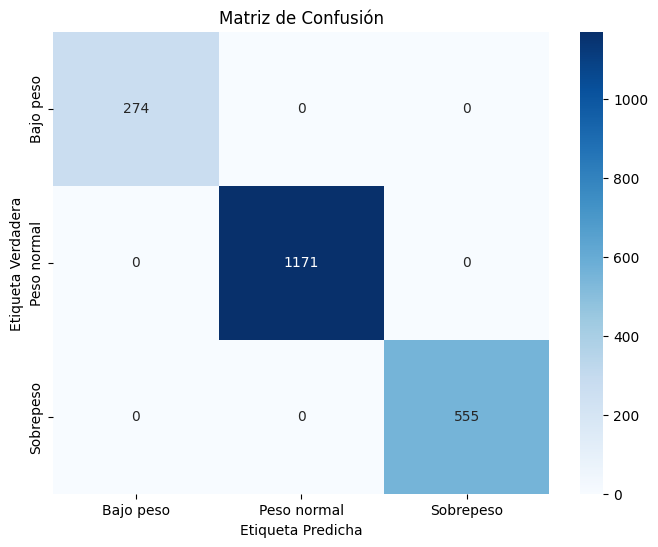

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.title('Matriz de Confusión')
plt.show()

### Métricas de Desempeño para Modelos de Regresión

Los modelos de regresión predicen un valor continuo. Por lo tanto, las métricas de desempeño se centran en qué tan cerca están las predicciones de los valores reales.

1.  **Error Cuadrático Medio (Mean Squared Error - MSE)**:
    *   **Fórmula:** $ MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $
    *   **Descripción:** Mide el promedio de los cuadrados de los errores (la diferencia entre los valores predichos y los valores reales). Penaliza más fuertemente los errores grandes debido al término al cuadrado. La unidad de MSE es la unidad de la variable objetivo al cuadrado.

2.  **Raíz del Error Cuadrático Medio (Root Mean Squared Error - RMSE)**:
    *   **Fórmula:** $ RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 } $
    *   **Descripción:** Es la raíz cuadrada del MSE. Es una de las métricas más utilizadas porque tiene la misma unidad que la variable objetivo, lo que facilita su interpretación. Un RMSE más bajo indica un mejor ajuste del modelo.

3.  **Error Absoluto Medio (Mean Absolute Error - MAE)**:
    *   **Fórmula:** $ MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $
    *   **Descripción:** Mide el promedio de las diferencias absolutas entre las predicciones y los valores reales. Es menos sensible a los valores atípicos que el MSE/RMSE porque no eleva al cuadrado los errores. También tiene la misma unidad que la variable objetivo.

4.  **R-cuadrado (R-squared o Coeficiente de Determinación)**:
    *   **Fórmula:** $ R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2} $
    *   **Descripción:** Representa la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes. Su valor oscila entre 0 y 1 (aunque puede ser negativo en casos de modelos muy pobres). Un valor más cercano a 1 indica que el modelo explica una mayor proporción de la variabilidad de la respuesta.

### Métricas de Desempeño para Modelos de Clasificación

Los modelos de clasificación predicen una categoría o clase discreta. Las métricas se centran en cuántas predicciones fueron correctas y cómo se distribuyen los errores (falsos positivos y falsos negativos). Estas métricas suelen derivarse de la Matriz de Confusión.

1.  **Precisión (Accuracy)**:
    *   **Fórmula:** $ Accuracy = \frac{VP + VN}{VP + VN + FP + FN} $
    *   **Descripción:** La proporción de predicciones correctas sobre el total de casos. Es una métrica intuitiva, pero puede ser engañosa en conjuntos de datos desequilibrados.

2.  **Sensibilidad (Recall o Exhaustividad)**:
    *   **Fórmula:** $ Recall = \frac{VP}{VP + FN} $
    *   **Descripción:** La proporción de positivos reales que fueron identificados correctamente. Responde a la pregunta: 'De todos los casos positivos reales, ¿cuántos predijo correctamente el modelo?' Es crucial cuando el costo de un Falso Negativo es alto.

3.  **Especificidad**:
    *   **Fórmula:** $ Specificity = \frac{VN}{VN + FP} $
    *   **Descripción:** La proporción de negativos reales que fueron identificados correctamente. Responde a la pregunta: 'De todos los casos negativos reales, ¿cuántos predijo correctamente el modelo?' Es importante cuando el costo de un Falso Positivo es alto.

4.  **Precisión (Precision)**:
    *   **Fórmula:** $ Precision = \frac{VP}{VP + FP} $
    *   **Descripción:** La proporción de predicciones positivas que fueron realmente correctas. Responde a la pregunta: 'De todas las predicciones positivas, ¿cuántas fueron realmente positivas?' Es importante cuando el costo de un Falso Positivo es alto.

5.  **Puntuación F1 (F1-Score)**:
    *   **Fórmula:** $ F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall} $
    *   **Descripción:** Es la media armónica de la Precision y el Recall. Es una métrica útil cuando se busca un equilibrio entre Precision y Recall, especialmente en clases desequilibradas.